# Prédiction de Maladie Cardiaque avec Régression Logistique

Dataset: Heart Disease UCI

## 1. Préparation des données

### 1.1 Analyse exploratoire des données (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Charger l'ensemble de données Heart Disease UCI
df = pd.read_csv('heart_disease.csv')

print("Shape du dataset:", df.shape)
print("\nPremières lignes:")
print(df.head())
print("\nTypes de données:")
print(df.dtypes)
print("\nValeurs manquantes:")
print(df.isnull().sum())
print("\nStatistiques descriptives:")
print(df.describe())

Shape du dataset: (303, 14)

Premières lignes:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang   oldpeak  \
0   67    1   3       126   458    1        2      154      1  5.414687   
1   57    0   1       158   384    1        2       76      0  1.002938   
2   43    0   4       111   286    1        1      201      1  4.874911   
3   71    1   3       189   515    0        2       71      1  3.562442   
4   36    0   1       142   303    0        1      128      1  3.512767   

   slope  ca  thal  target  
0      3   0     2       1  
1      1   3     3       1  
2      2   3     2       1  
3      1   0     1       1  
4      1   3     1       0  

Types de données:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Valeurs manqua


=== ANALYSE EXPLORATOIRE DES DONNÉES ===

Distribution de la variable cible (target):
target
0    152
1    151
Name: count, dtype: int64

Pourcentage:
target
0    50.165017
1    49.834983
Name: proportion, dtype: float64


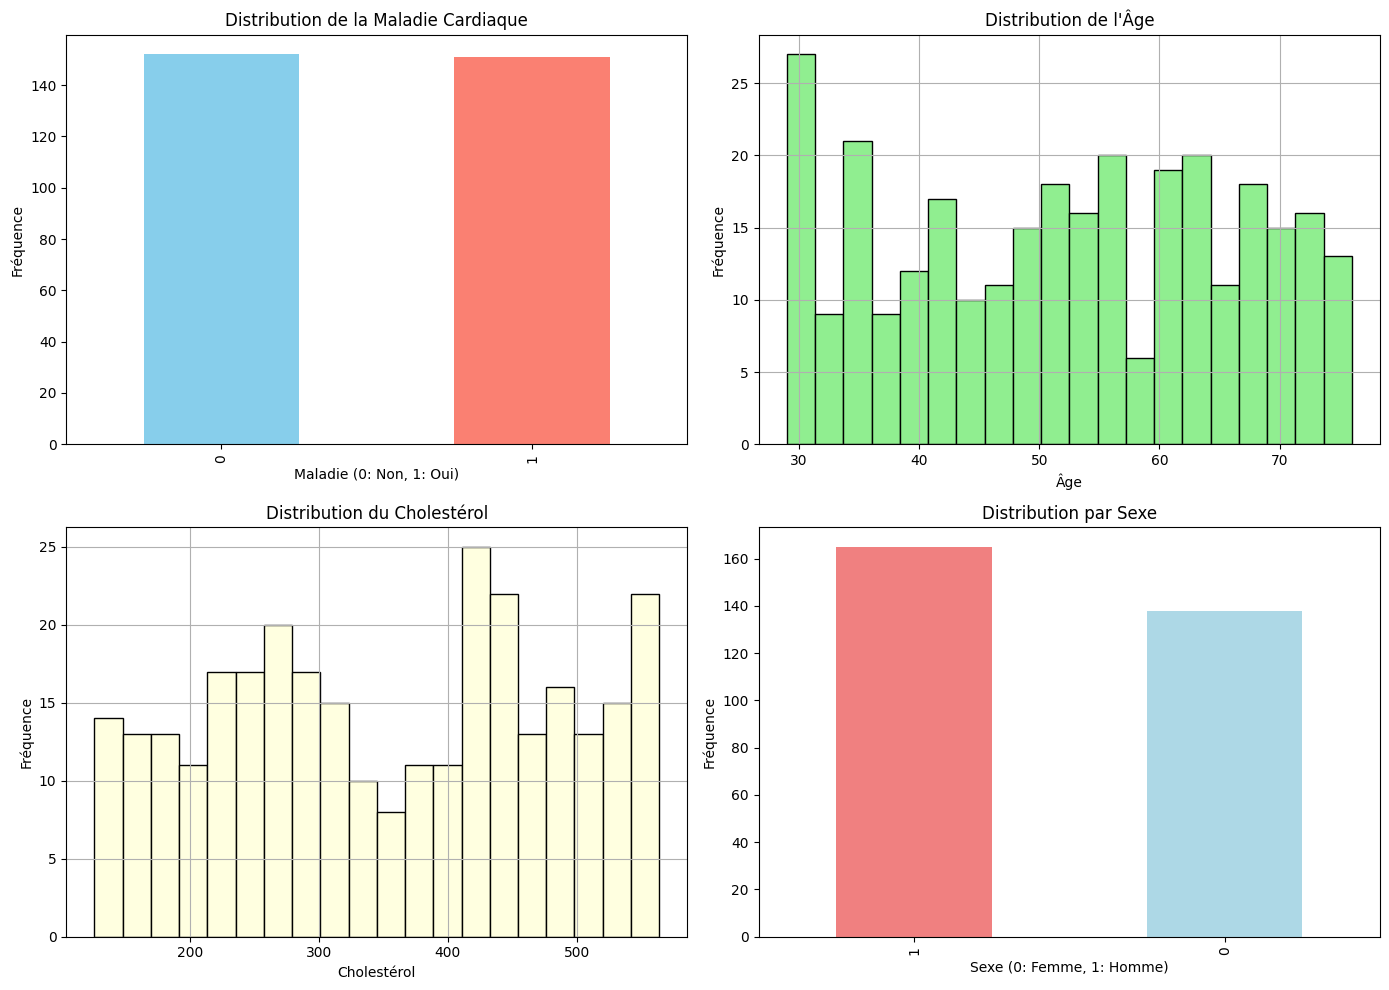

In [ ]:
# Analyse exploratoire détaillée
print("\n=== ANALYSE EXPLORATOIRE DES DONNÉES ===")
print("\nDistribution de la variable cible (target):")
print(df['target'].value_counts())
print("\nPourcentage:")
print(df['target'].value_counts(normalize=True) * 100)

# Visualisations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution de la cible
df['target'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['skyblue', 'salmon'])
axes[0, 0].set_title('Distribution de la Maladie Cardiaque')
axes[0, 0].set_xlabel('Maladie (0: Non, 1: Oui)')
axes[0, 0].set_ylabel('Fréquence')

# Distribution de l'âge
df['age'].hist(bins=20, ax=axes[0, 1], color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribution de l\'Âge')
axes[0, 1].set_xlabel('Âge')
axes[0, 1].set_ylabel('Fréquence')

# Distribution du cholestérol
df['chol'].hist(bins=20, ax=axes[1, 0], color='lightyellow', edgecolor='black')
axes[1, 0].set_title('Distribution du Cholestérol')
axes[1, 0].set_xlabel('Cholestérol')
axes[1, 0].set_ylabel('Fréquence')

# Distribution du sexe
df['sex'].value_counts().plot(kind='bar', ax=axes[1, 1], color=['lightcoral', 'lightblue'])
axes[1, 1].set_title('Distribution par Sexe')
axes[1, 1].set_xlabel('Sexe (0: Femme, 1: Homme)')
axes[1, 1].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()


Matrice de corrélation:
target      1.000000
ca          0.057962
thal        0.055197
age         0.049783
slope       0.049413
oldpeak     0.016423
cp          0.001138
restecg    -0.004087
trestbps   -0.007225
fbs        -0.023294
sex        -0.029527
chol       -0.037396
thalach    -0.053690
exang      -0.069229
Name: target, dtype: float64


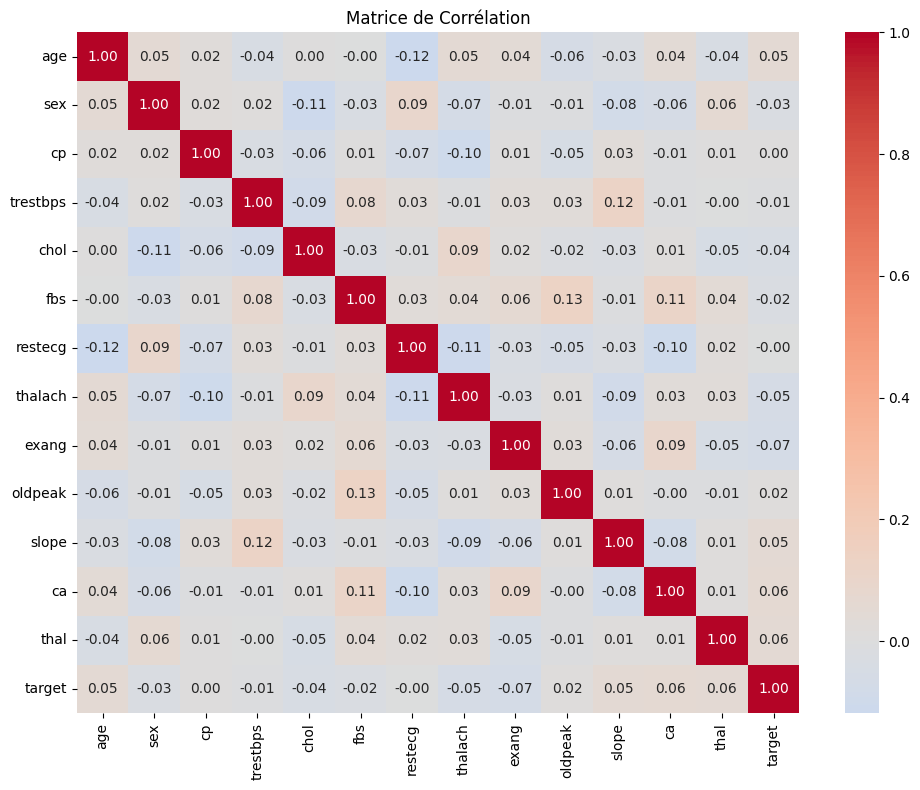

In [ ]:
# Corrélation
print("\nMatrice de corrélation:")
correlation = df.corr()
print(correlation['target'].sort_values(ascending=False))

# Visualiser la corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matrice de Corrélation')
plt.tight_layout()
plt.show()

### 1.2 Prétraitement des données

In [ ]:
print("\n=== PRÉTRAITEMENT DES DONNÉES ===")

# Vérifier les valeurs manquantes
print("\nValeurs manquantes:")
print(df.isnull().sum())

# Aucune valeur manquante à gérer (déjà propres)
print("\n✓ Pas de valeurs manquantes détectées")


=== PRÉTRAITEMENT DES DONNÉES ===

Valeurs manquantes:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

✓ Pas de valeurs manquantes détectées


In [ ]:
# Séparer les features et la cible
X = df.drop('target', axis=1)
y = df['target']

print("\nShape de X:", X.shape)
print("Shape de y:", y.shape)
print("\nColonnes des features:")
print(X.columns.tolist())


Shape de X: (303, 13)
Shape de y: (303,)

Colonnes des features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [ ]:
# Encoder les variables catégorielles
print("\nVérification des variables catégorielles:")
categorical_cols = X.select_dtypes(include=['object']).columns
print(f"Colonnes catégorielles: {categorical_cols.tolist()}")
print("✓ Toutes les colonnes sont numériques - aucun encodage nécessaire")


Vérification des variables catégorielles:
Colonnes catégorielles: []
✓ Toutes les colonnes sont numériques - aucun encodage nécessaire


In [ ]:
# Mettre à l'échelle les features
print("\nMise à l'échelle des features avec StandardScaler:")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nAprès la mise à l'échelle - Premières lignes:")
print(X_scaled.head())
print("\nMoyenne de chaque feature (doit être ~0):")
print(X_scaled.mean())
print("\nEcart-type de chaque feature (doit être ~1):")
print(X_scaled.std())


Mise à l'échelle des features avec StandardScaler:

Après la mise à l'échelle - Premières lignes:
        age       sex        cp  trestbps      chol       fbs   restecg  \
0  1.061950  0.914529  0.511737 -0.655648  0.817101  1.050793  1.238297   
1  0.341137 -1.093459 -1.201591  0.367226  0.239077  1.050793  1.238297   
2 -0.668001 -1.093459  1.368401 -1.135121 -0.526413  1.050793  0.027962   
3  1.350275  0.914529  0.511737  1.358137  1.262335 -0.951662  1.238297   
4 -1.172570 -1.093459 -1.201591 -0.144211 -0.393624 -0.951662  0.027962   

    thalach     exang   oldpeak     slope        ca      thal  
0  0.474529  0.951662  1.352749  1.283438 -1.254862 -0.047178  
1 -1.525296 -1.050793 -1.138996 -1.217409  1.320013  1.144057  
2  1.679552  0.951662  1.047885  0.033014  1.320013 -0.047178  
3 -1.653490  0.951662  0.306605 -1.217409 -1.254862 -1.238412  
4 -0.192079  0.951662  0.278549 -1.217409  1.320013 -1.238412  

Moyenne de chaque feature (doit être ~0):
age        -6.815230e-1

## 2. Formation du modèle

In [ ]:
# Diviser l'ensemble de données en ensemble d'entraînement et ensemble de test
print("\n=== DIVISION TRAIN/TEST ===")
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Taille de l'ensemble d'entraînement: {X_train.shape[0]}")
print(f"Taille de l'ensemble de test: {X_test.shape[0]}")
print(f"\nDistribution de y_train:")
print(y_train.value_counts())
print(f"\nDistribution de y_test:")
print(y_test.value_counts())


=== DIVISION TRAIN/TEST ===
Taille de l'ensemble d'entraînement: 242
Taille de l'ensemble de test: 61

Distribution de y_train:
target
1    121
0    121
Name: count, dtype: int64

Distribution de y_test:
target
0    31
1    30
Name: count, dtype: int64


In [ ]:
# Entraîner le modèle de régression logistique
print("\n=== ENTRAÎNEMENT DU MODÈLE DE RÉGRESSION LOGISTIQUE ===")
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

print("✓ Modèle entraîné avec succès!")
print(f"\nCoefficients du modèle:")
for feature, coef in zip(X_scaled.columns, lr_model.coef_[0]):
    print(f"  {feature}: {coef:.6f}")
print(f"\nIntercept (constante): {lr_model.intercept_[0]:.6f}")


=== ENTRAÎNEMENT DU MODÈLE DE RÉGRESSION LOGISTIQUE ===
✓ Modèle entraîné avec succès!

Coefficients du modèle:
  age: 0.129185
  sex: -0.084030
  cp: -0.033171
  trestbps: -0.118574
  chol: -0.102962
  fbs: 0.035862
  restecg: 0.029954
  thalach: -0.245459
  exang: -0.214809
  oldpeak: 0.132296
  slope: 0.129277
  ca: 0.198695
  thal: 0.120065

Intercept (constante): 0.020336


## 3. Évaluation du modèle

In [ ]:
# Faire les prédictions
y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

print("\n=== ÉVALUATION DU MODÈLE ===")
print("\n--- ENSEMBLE D'ENTRAÎNEMENT ---")
print(f"Exactitude (Accuracy): {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Précision (Precision): {precision_score(y_train, y_pred_train):.4f}")
print(f"Rappel (Recall): {recall_score(y_train, y_pred_train):.4f}")
print(f"Score F1: {f1_score(y_train, y_pred_train):.4f}")

print("\n--- ENSEMBLE DE TEST ---")
print(f"Exactitude (Accuracy): {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Précision (Precision): {precision_score(y_test, y_pred_test):.4f}")
print(f"Rappel (Recall): {recall_score(y_test, y_pred_test):.4f}")
print(f"Score F1: {f1_score(y_test, y_pred_test):.4f}")


=== ÉVALUATION DU MODÈLE ===

--- ENSEMBLE D'ENTRAÎNEMENT ---
Exactitude (Accuracy): 0.6281
Précision (Precision): 0.6325
Rappel (Recall): 0.6116
Score F1: 0.6218

--- ENSEMBLE DE TEST ---
Exactitude (Accuracy): 0.4098
Précision (Precision): 0.4118
Rappel (Recall): 0.4667
Score F1: 0.4375


In [ ]:
# Matrice de confusion
print("\n=== MATRICE DE CONFUSION ===")
cm_train = confusion_matrix(y_train, y_pred_train)
cm_test = confusion_matrix(y_test, y_pred_test)

print("\nMatrice de confusion - Ensemble d'entraînement:")
print(cm_train)
print("\nMatrice de confusion - Ensemble de test:")
print(cm_test)


=== MATRICE DE CONFUSION ===

Matrice de confusion - Ensemble d'entraînement:
[[78 43]
 [47 74]]

Matrice de confusion - Ensemble de test:
[[11 20]
 [16 14]]


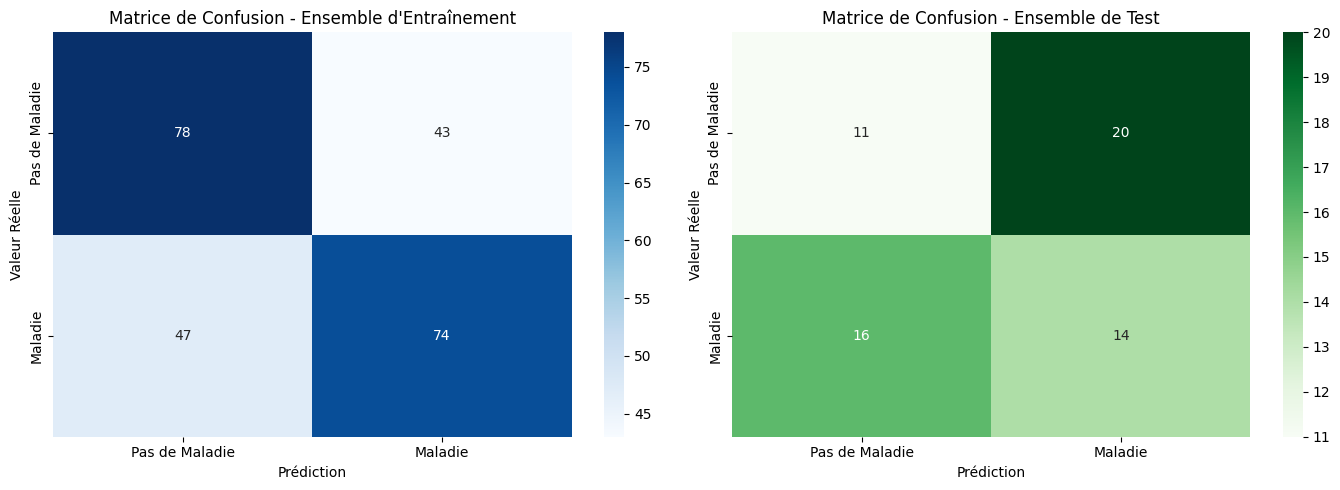

In [ ]:
# Visualiser les matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ensemble d'entraînement
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pas de Maladie', 'Maladie'],
            yticklabels=['Pas de Maladie', 'Maladie'])
axes[0].set_title('Matrice de Confusion - Ensemble d\'Entraînement')
axes[0].set_ylabel('Valeur Réelle')
axes[0].set_xlabel('Prédiction')

# Ensemble de test
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Pas de Maladie', 'Maladie'],
            yticklabels=['Pas de Maladie', 'Maladie'])
axes[1].set_title('Matrice de Confusion - Ensemble de Test')
axes[1].set_ylabel('Valeur Réelle')
axes[1].set_xlabel('Prédiction')

plt.tight_layout()
plt.show()

In [ ]:
# Rapport de classification
print("\n=== RAPPORT DE CLASSIFICATION ===")
print("\nEnsemble d'entraînement:")
print(classification_report(y_train, y_pred_train,
                          target_names=['Pas de Maladie', 'Maladie']))

print("\nEnsemble de test:")
print(classification_report(y_test, y_pred_test,
                          target_names=['Pas de Maladie', 'Maladie']))


=== RAPPORT DE CLASSIFICATION ===

Ensemble d'entraînement:
                precision    recall  f1-score   support

Pas de Maladie       0.62      0.64      0.63       121
       Maladie       0.63      0.61      0.62       121

      accuracy                           0.63       242
     macro avg       0.63      0.63      0.63       242
  weighted avg       0.63      0.63      0.63       242


Ensemble de test:
                precision    recall  f1-score   support

Pas de Maladie       0.41      0.35      0.38        31
       Maladie       0.41      0.47      0.44        30

      accuracy                           0.41        61
     macro avg       0.41      0.41      0.41        61
  weighted avg       0.41      0.41      0.41        61



In [ ]:
# Résumé des performances
print("\n" + "="*60)
print("RÉSUMÉ DES PERFORMANCES DU MODÈLE")
print("="*60)
print("\n--- ENSEMBLE DE TEST ---")
print(f"Exactitude (Accuracy): {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Précision (Precision): {precision_score(y_test, y_pred_test):.4f}")
print(f"Rappel (Recall): {recall_score(y_test, y_pred_test):.4f}")
print(f"Score F1: {f1_score(y_test, y_pred_test):.4f}")
print("\nMatrice de confusion:")
print(cm_test)
print(f"\nVrai Négatifs (TN): {cm_test[0, 0]}")
print(f"Faux Positifs (FP): {cm_test[0, 1]}")
print(f"Faux Négatifs (FN): {cm_test[1, 0]}")
print(f"Vrai Positifs (TP): {cm_test[1, 1]}")


RÉSUMÉ DES PERFORMANCES DU MODÈLE

--- ENSEMBLE DE TEST ---
Exactitude (Accuracy): 0.4098
Précision (Precision): 0.4118
Rappel (Recall): 0.4667
Score F1: 0.4375

Matrice de confusion:
[[11 20]
 [16 14]]

Vrai Négatifs (TN): 11
Faux Positifs (FP): 20
Faux Négatifs (FN): 16
Vrai Positifs (TP): 14
